## Libraries

In [790]:
import numpy as np
import torch 
import torch.nn as nn 
import scipy.io 
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.tensorboard import SummaryWriter
#writer = SummaryWriter()

#import xlsxwriter




## Load Data

In [791]:
data = scipy.io.loadmat('/Users/ramtarun/Desktop/Cambridge/Indirect-Noise-in-Nozzles/Data/Data_PINN_ff0.01He0N551_subsonic.mat')

## Data Preprocessing

In [792]:
U = torch.zeros((551,4))
U[:,0] = torch.from_numpy(data['eta'])
U[:,1] = torch.from_numpy(data['pi_p'])
U[:,2] = torch.from_numpy(data['pi_m'])
U[:,3] = torch.from_numpy(data['sig'])

eta = U[:, 0]
pi_p = U[:, 1]
pi_m = U[:, 2]
sig = U[:, 3]

N1 = eta.shape[0]

D = torch.from_numpy(data['D'])
M = torch.from_numpy(data['M'])
u = torch.from_numpy(data['ubar'])
dMdx = torch.from_numpy(data['dMdx'])
dudx = torch.from_numpy(data['dudx'])
alpha = torch.from_numpy(data['alp'])
eta1 = torch.from_numpy(data['eta'])    

#print(N1)

meanflow = torch.zeros((N1,7))
meanflow[:,0] = D
meanflow[:,1] = M
meanflow[:,2] = u
meanflow[:,3] = dMdx
meanflow[:,4] = dudx
meanflow[:,5] = alpha
meanflow[:,6] = eta1

#print(meanflow)

he = torch.tensor([0.00])
HE = torch.tile(he, (1,N1)) 
He = HE.flatten()[:,None]
ETA = eta.flatten()[:, None]
UU = U[:, 1:4]



## Split Dataset into Training and Testing Dataset

In [793]:
split_ratio = 0.85
He_t, He_test = train_test_split(He, train_size = split_ratio, shuffle = False, random_state=45)
Eta_t, Eta_test, UU_t, UU_test = train_test_split(ETA, UU, train_size = split_ratio, shuffle=False, random_state=45)
meanflow_t, meanflow_test = train_test_split(meanflow, train_size = split_ratio, shuffle=False, random_state=45)

He_train, He_val = train_test_split(He_t, test_size = 0.15, shuffle = False, random_state=45)
Eta_train, Eta_val, UU_train, UU_val = train_test_split(Eta_t, UU_t, test_size = 0.15, shuffle=False, random_state=45)
meanflow_train, meanflow_val = train_test_split(meanflow_t, test_size = 0.15, shuffle=False, random_state=45)

## Visualizing the Train and Test Dataset

Text(0.5, 1.0, 'Testing Data')

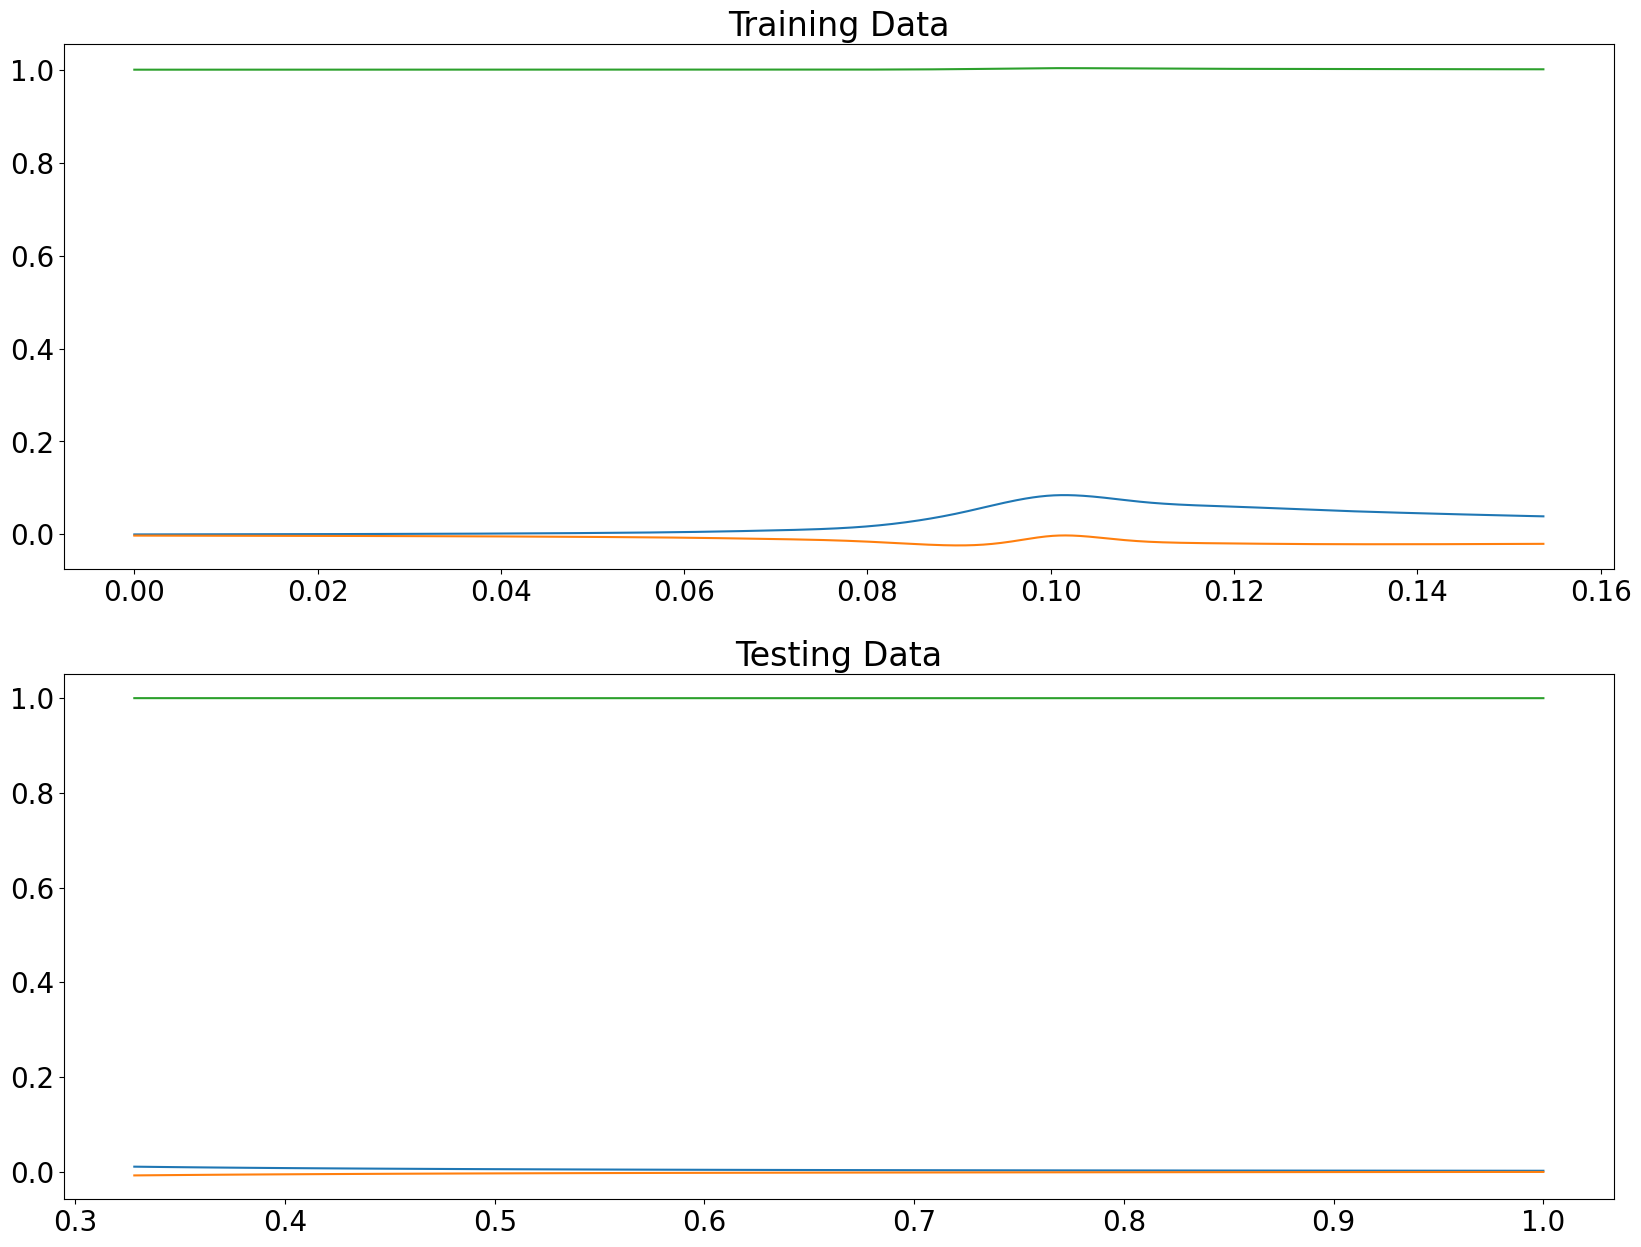

In [794]:
plt.rcParams["figure.figsize"] = (20,15)
plt.rcParams["font.size"]  = 20
plt.subplot(2,1,1)
plt.plot(Eta_train.detach(), UU_train.detach())
plt.title("Training Data")
plt.subplot(2,1,2)
plt.plot(Eta_test.detach(), UU_test.detach())
plt.title("Testing Data")

## Governing Partial Differential Equation Estimation

In [795]:
def RHS(y, baseflow):
    
    pi_p, pi_m, sig = torch.unbind(y,axis=1)

    D = baseflow[:,0]
    M = baseflow[:,1]
    u = baseflow[:,2]
    dMdx = baseflow[:,3]
    dudx = baseflow[:,4]
    alpha = baseflow[:,5]
    eta1 = baseflow[:,6]    
    
    He = 0 #a constant input

    gamma = 1.4 #constant

    f = 0.01
    
    Msq = torch.square(M)

    Lambda = 1 + Msq * (gamma-1)/2
    zeta = f*gamma*Msq - 2*torch.tan(alpha)
    C1= ((gamma - 1)*(1-Msq)*f)/(2*Lambda*zeta)
    Ca = -C1*M*u*dMdx*(2-(2*Msq/(1-Msq)) - (2*gamma*Msq*(-2*f*Lambda - (gamma-1)/gamma *zeta)/(2*Lambda*zeta)))
    Ff = -(dudx + (4*f*u/(2*D)))
    
    denom = (Msq*u - u + C1*Msq *u + C1*Msq*Msq*gamma*u) #M**4
    vrh_p = M*(2*(1-M) + C1*M*(M-2+M*gamma*(1-2*M)))/(2*denom)
    vrh_m = -M*(2*(1+M) + C1*M*(M+2+M*gamma*(1+2*M)))/(2*denom)
    vkp_p = Msq*C1*(2+M*(gamma-1))/(2*denom)
    vkp_m = Msq*C1*(2-M*(gamma-1))/(2*denom)
    vth_p = C1*M*(M*(1+gamma) + M**2*(1-gamma) - 2)/denom
    vth_m = C1*M*(M*(1+gamma) - M**2*(1-gamma) + 2)/denom
    vsig = -(C1*Msq*(1+gamma*Msq) + Msq - 1)/denom
    calM = dMdx/(2*M)
    kp_p = (gamma - 1) + (2/M)
    kp_m = (gamma - 1) - (2/M)
    Gm_p = M*(Ca*(M + 1) + Ff*M*(C1*gamma*M*Msq + M + (1 - C1*Msq)))/(2*denom)
    Gm_m = M*(Ca*(M - 1) - Ff*M*(C1*gamma*M*Msq + M - (1 - C1*Msq)))/(2*denom)
    Ups = (Ca*(Msq - 1) - C1*Ff*Msq*Msq *(1+gamma))/denom
    
#     eq1 = - (2*np.pi*1j*He*vrh_p + Gm_m*kp_m + calM)*pi_p + (2*np.pi*1j*He*vkp_p + Gm_m*kp_p + calM)*pi_m - Gm_m*sig
#     eq2 = - (2*np.pi*1j*He*vkp_m + Gm_p*kp_m - calM)*pi_p - (2*np.pi*1j*He*vrh_m + Gm_p*kp_p + calM)*pi_m - Gm_m*sig
#     eq3 = - (2*np.pi*1j*He*vth_p + Ups*kp_m)*pi_p - (2*np.pi*1j*He*vth_m + Ups*kp_p)*pi_m - (2*np.pi*1j*He*vsig + Ups)*sig
#     eq1 = - tf.multiply((Gm_m*kp_m + calM),pi_p) + tf.multiply(( Gm_m*kp_p + calM),pi_m) - tf.multiply(Gm_m,sig)

    eq1 =  (Gm_m*kp_m + calM)*pi_p + ( Gm_m*kp_p - calM)*pi_m + Gm_m*sig
    eq2 =  (Gm_p*kp_m - calM)*pi_p + ( Gm_p*kp_p + calM)*pi_m + Gm_p*sig
    eq3 =  (Ups*kp_m)*pi_p + ( Ups*kp_p)*pi_m + (Ups)*sig
    
    return torch.stack([-eq1, -eq2, -eq3], axis=1)

In [796]:
def RHS_f(y, baseflow, f):
    
    pi_p, pi_m, sig = torch.unbind(y,axis=1)

    D = baseflow[:,0]
    M = baseflow[:,1]
    u = baseflow[:,2]
    dMdx = baseflow[:,3]
    dudx = baseflow[:,4]
    alpha = baseflow[:,5]
    eta1 = baseflow[:,6]    
    
    He = 0 #a constant input

    gamma = 1.4 #constant
    
    Msq = torch.square(M)

    Lambda = 1 + Msq * (gamma-1)/2
    zeta = f*gamma*Msq - 2*torch.tan(alpha)
    C1= ((gamma - 1)*(1-Msq)*f)/(2*Lambda*zeta)
    Ca = -C1*M*u*dMdx*(2-(2*Msq/(1-Msq)) - (2*gamma*Msq*(-2*f*Lambda - (gamma-1)/gamma *zeta)/(2*Lambda*zeta)))
    Ff = -(dudx + (4*f*u/(2*D)))
    
    denom = (Msq*u - u + C1*Msq *u + C1*Msq*Msq*gamma*u) #M**4
    vrh_p = M*(2*(1-M) + C1*M*(M-2+M*gamma*(1-2*M)))/(2*denom)
    vrh_m = -M*(2*(1+M) + C1*M*(M+2+M*gamma*(1+2*M)))/(2*denom)
    vkp_p = Msq*C1*(2+M*(gamma-1))/(2*denom)
    vkp_m = Msq*C1*(2-M*(gamma-1))/(2*denom)
    vth_p = C1*M*(M*(1+gamma) + M**2*(1-gamma) - 2)/denom
    vth_m = C1*M*(M*(1+gamma) - M**2*(1-gamma) + 2)/denom
    vsig = -(C1*Msq*(1+gamma*Msq) + Msq - 1)/denom
    calM = dMdx/(2*M)
    kp_p = (gamma - 1) + (2/M)
    kp_m = (gamma - 1) - (2/M)
    Gm_p = M*(Ca*(M + 1) + Ff*M*(C1*gamma*M*Msq + M + (1 - C1*Msq)))/(2*denom)
    Gm_m = M*(Ca*(M - 1) - Ff*M*(C1*gamma*M*Msq + M - (1 - C1*Msq)))/(2*denom)
    Ups = (Ca*(Msq - 1) - C1*Ff*Msq*Msq *(1+gamma))/denom
    
#     eq1 = - (2*np.pi*1j*He*vrh_p + Gm_m*kp_m + calM)*pi_p + (2*np.pi*1j*He*vkp_p + Gm_m*kp_p + calM)*pi_m - Gm_m*sig
#     eq2 = - (2*np.pi*1j*He*vkp_m + Gm_p*kp_m - calM)*pi_p - (2*np.pi*1j*He*vrh_m + Gm_p*kp_p + calM)*pi_m - Gm_m*sig
#     eq3 = - (2*np.pi*1j*He*vth_p + Ups*kp_m)*pi_p - (2*np.pi*1j*He*vth_m + Ups*kp_p)*pi_m - (2*np.pi*1j*He*vsig + Ups)*sig
#     eq1 = - tf.multiply((Gm_m*kp_m + calM),pi_p) + tf.multiply(( Gm_m*kp_p + calM),pi_m) - tf.multiply(Gm_m,sig)

    eq1 =  (Gm_m*kp_m + calM)*pi_p + ( Gm_m*kp_p - calM)*pi_m + Gm_m*sig
    eq2 =  (Gm_p*kp_m - calM)*pi_p + ( Gm_p*kp_p + calM)*pi_m + Gm_p*sig
    eq3 =  (Ups*kp_m)*pi_p + ( Ups*kp_p)*pi_m + (Ups)*sig
    
    return torch.stack([-eq1, -eq2, -eq3], axis=1)

## Hyperparameters for Tuning the model

In [797]:
torch.cuda.manual_seed(22)
#layers = np.array([2, 8, 8, 8, 8, 3])  # Number of nodes in each layer of Neural Networks
epochs= 6000
learning_rate= 1e-3
#ff_learning_rate = 1e-3
batch_size = 4
input_size = 2
hidden_sizes = [8, 8, 8, 8, 8, 8, 8, 8]
output_size = 4
activations = [nn.ReLU(), nn.Tanh(), nn.ReLU(), nn.Tanh(), nn.ReLU(), nn.Tanh(), nn.ReLU(), nn.Tanh()]
lda = torch.tensor([0.0001])

## Deep Neural Netowrks 
    DNN architeecture is used to predict the dependant variables of the PDE. 

In [798]:
# Neural Network for Predicting the pi+, pi-, and si.

class NN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.input_layer = nn.Linear(input_size, hidden_sizes[0])
        self.hidden_layers = nn.ModuleList()
        for i in range(len(hidden_sizes) - 1):
            self.hidden_layers.append(nn.Linear(hidden_sizes[i], hidden_sizes[i + 1]))
        self.output_layer = nn.Linear(hidden_sizes[-1], output_size)
        
        self.activations = nn.ModuleList(activations)
    
    def forward(self, x):
        x = self.activations[0](self.input_layer(x))
        for i, hidden_layer in enumerate(self.hidden_layers):
            x = self.activations[i+1](hidden_layer(x))
        x = self.output_layer(x)
        return x

## Physics Informed Neural Networks 
    Predicted variables from the DNN, are then trained by minimizing a loss function, which is obtained by imposing the physics and constraints. 

In [799]:
# Physics informed Neural Network 
#f = torch.empty(1)

class PINN(nn.Module):
    def __init__(self):   
        super().__init__()
        self.loss_function = nn.MSELoss()
        'Initialize our new parameters i.e.f (Inverse problem)' 
        #self.f = torch.tensor([f], requires_grad=True).type(torch.float32)
        #nn.init.zeros_(self.f)
        'Register f to optimize'
        #self.f = nn.Parameter(self.f)
        'Initialize iterator'
        self.iter = 0
        'Call our DNN'
        self.dnn = NN()
        'Register our new parameter'
        #self.dnn.register_parameter('f', self.f)  

        'Regularisation Constant'
        self.lda = torch.tensor([lda])

    def loss_data(self, X, UU):
        preds = self.dnn(X)
        outs = preds[:, :3]
        loss_u = self.loss_function(outs, UU)
        return loss_u
    
    def loss_residual(self, X, meanflow):
        g = torch.clone(X)
        preds = self.dnn(g)
        outs = preds[:, :3]
        f = torch.mean(preds[:,3])
        GR = RHS_f(outs, meanflow, f)
        dr_dn = torch.autograd.grad(outs,g,torch.ones_like(outs), retain_graph=True, create_graph=True)[0]
        pde = dr_dn[:, 1:] + GR
        return torch.mean(pde**2) 
    
    def Loss(self, X, UU, meanflow):
        loss_data = self.loss_data(X, UU)
        loss_residual = self.loss_residual(X, meanflow)
        return loss_data + lda*loss_residual 
    
    
    'test neural network'
    def test(self, X_test, UU_test):

        with torch.no_grad():
            
            u_pred = self.dnn(X_test)
        
            error_vec = torch.linalg.norm((UU_test-u_pred[:,:3]),2)/torch.linalg.norm(UU_test,2)        # Relative L2 Norm of the error (Vector)

            print('f_real = [0.01], f_PINN = [%.5f], Validation Loss = [%.5f] ' %(torch.mean(u_pred[:,3]), error_vec))

        plt.rcParams["figure.figsize"] = (20, 10)
        plt.rcParams["font.size"]  = 20
        plt.grid(linestyle=':')
        plt.plot(X_test[:,1].detach().cpu(), UU_test.detach().cpu(), 'black')
        plt.plot(X_test[:, 1].detach().cpu(), u_pred[:,:3].detach().cpu(), 'r--')

        return

In [800]:
Eta_train.requires_grad = True
Eta_test.requires_grad = True
UU_train.requires_grad = True
UU_test.requires_grad = True
meanflow_train.requires_grad = True
meanflow_test.requires_grad = True 

In [801]:
N_train = torch.cat([He_train, Eta_train],1)
N = N_train.shape[0]
N_val = torch.cat([He_val, Eta_val],1)
N_test = torch.cat([He_test, Eta_test],1)
PINN_model = PINN()

params = list(PINN_model.parameters())
#optimizer = torch.optim.LBFGS(params, learning_rate, 
                              #max_iter = epochs, 
                              #max_eval = None, 
                              #tolerance_grad = 1e-11, 
                              #tolerance_change = 1e-11, 
                              #history_size = 100, 
                              #line_search_fn = 'strong_wolfe')


optimizer = torch.optim.Adam(params=params, lr = learning_rate, amsgrad = True)                              
#optimizer = torch.optim.Adam([{'params' : params[1::]},{'params' : params[0], 'lr': ff_learning_rate}], lr = learning_rate, amsgrad = False)
criterion = nn.MSELoss() 

#writer.add_graph(PINN_model.dnn, N_train)


In [802]:
dataset = TensorDataset(N_train, UU_train, meanflow_train)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

dataset2 = TensorDataset(N_val, UU_val, meanflow_val)
val_loader = DataLoader(dataset2, batch_size=batch_size, shuffle=True)

dataset3 = TensorDataset(N_test, UU_test, meanflow_test)
test_loader = DataLoader(dataset3, batch_size=batch_size, shuffle=False)

In [803]:
losses = {}
friction_f = {}
for i in range(epochs):
    running_loss = 0.0
    for j, (X, Y, MF) in enumerate(train_loader):
        optimizer.zero_grad()
        loss = PINN_model.Loss(X, Y, MF)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() 
        ff = torch.mean(PINN_model.dnn(X)[:,3])
        # Print the loss after every 10 batches
        #if (i+1) % 10 == 0:
         #   print(f" Epoch [{i+1}/{epochs}], Batch [{j+1}/{len(dataloader)}], Running Loss: {running_loss/10:.4f}, Loss: {loss.item():.4f}")
          #  running_loss = 0.0


    epoch_loss = running_loss/N 
    losses[i] = epoch_loss
    #writer.add_scalar("Loss/epoch", epoch_loss, i)
    friction_f[i] = ff.item()
    #writer.add_scalar("Friction Factor/epoch", f.item(), i)

    # Print the loss after each epoch
    #print(f"Epoch [{i+1}/{epochs}], Loss: {loss.item():.4f}")

    if i == epochs-1:
        print(f"Epoch {i+1}/{epochs} - Loss: {epoch_loss:.6f}    f_Real: [0.01] - f_PINN:  {friction_f[i]:.6f}")
    elif (i+1) % (epochs//5) == 0:
        print(f"Epoch {i+1}/{epochs} - Loss: {epoch_loss:.6f}    f_Real: [0.01] - f_PINN:  {friction_f[i]:.6f}")




Epoch 1200/6000 - Loss: 0.000028    f_Real: [0.01] - f_PINN:  0.090238
Epoch 2400/6000 - Loss: 0.000027    f_Real: [0.01] - f_PINN:  0.097336
Epoch 3600/6000 - Loss: 0.000027    f_Real: [0.01] - f_PINN:  0.106934


KeyboardInterrupt: 

In [ ]:
R_pred = PINN_model.dnn(N_train)
#print(list(PINN_model.parameters()))

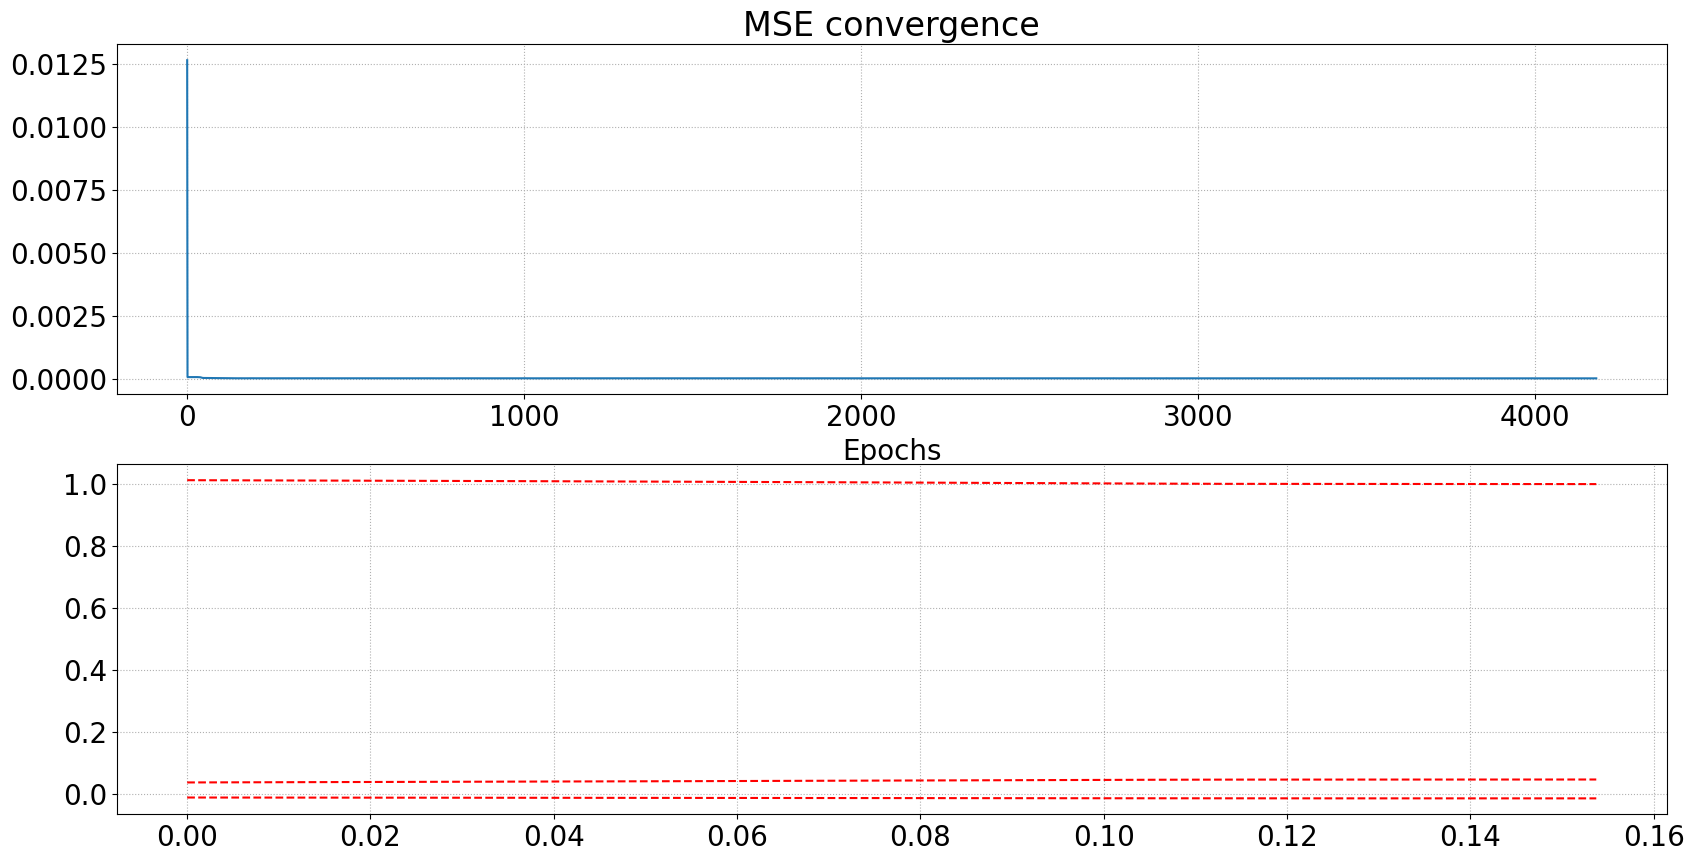

In [804]:
plt.rcParams["figure.figsize"] = (20, 10)
plt.rcParams["font.size"]  = 20
plt.subplot(2,1,1)
plt.grid(linestyle=':')
plt.plot(losses.keys(), losses.values())
plt.title('MSE convergence')
plt.xlabel('Epochs')
plt.subplot(2,1,2)
plt.grid(linestyle=':')
#plt.plot(Eta_train.detach().cpu(), UU_train.detach().cpu(), 'black')
plt.plot(Eta_train.detach().cpu(), R_pred[:,:3].detach().cpu(), 'r--')



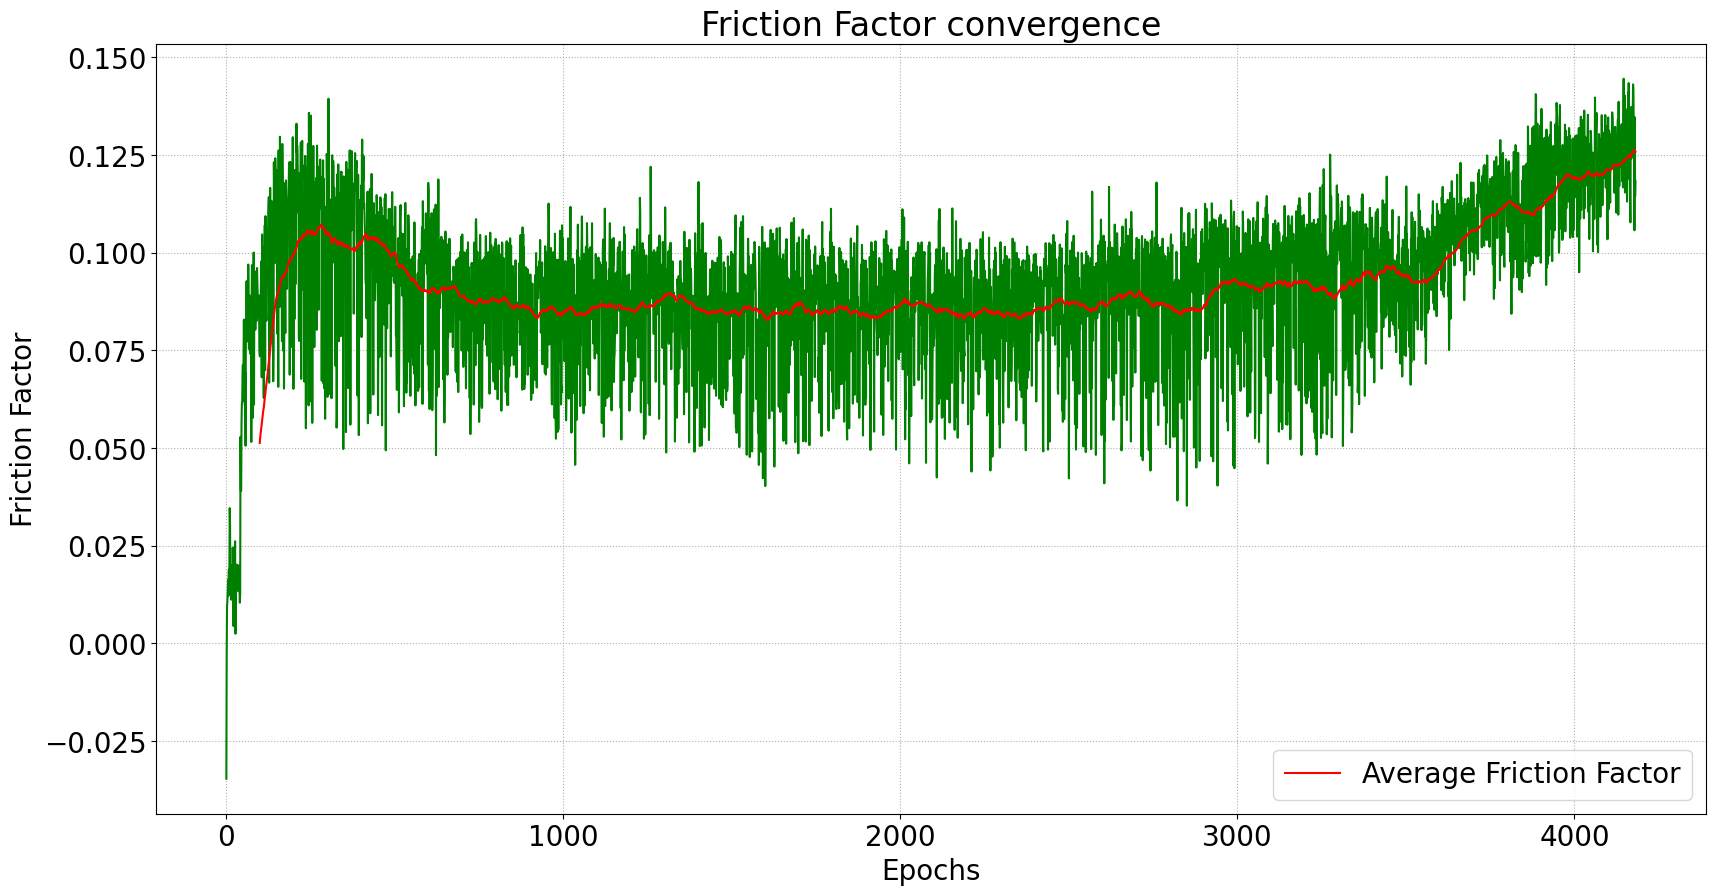

In [805]:
w = 100
ff = list(friction_f.values())
average_ff = []
for ind in range(len(ff)-w + 1):
    average_ff.append(np.mean(ff[ind:ind+w]))
for ind in range(w - 1):
    average_ff.insert(0, np.nan)

plt.rcParams["figure.figsize"] = (20, 10)
plt.rcParams["font.size"]  = 20
plt.title('Friction Factor convergence')
plt.xlabel('Epochs')
plt.ylabel('Friction Factor')
plt.grid(linestyle=':')
plt.plot(friction_f.keys(), friction_f.values(), 'g-')
plt.plot(friction_f.keys(), average_ff, 'r-', label='Average Friction Factor')
plt.legend()


f_real = [0.01], f_PINN = [0.00909], Validation Loss = [0.02480] 


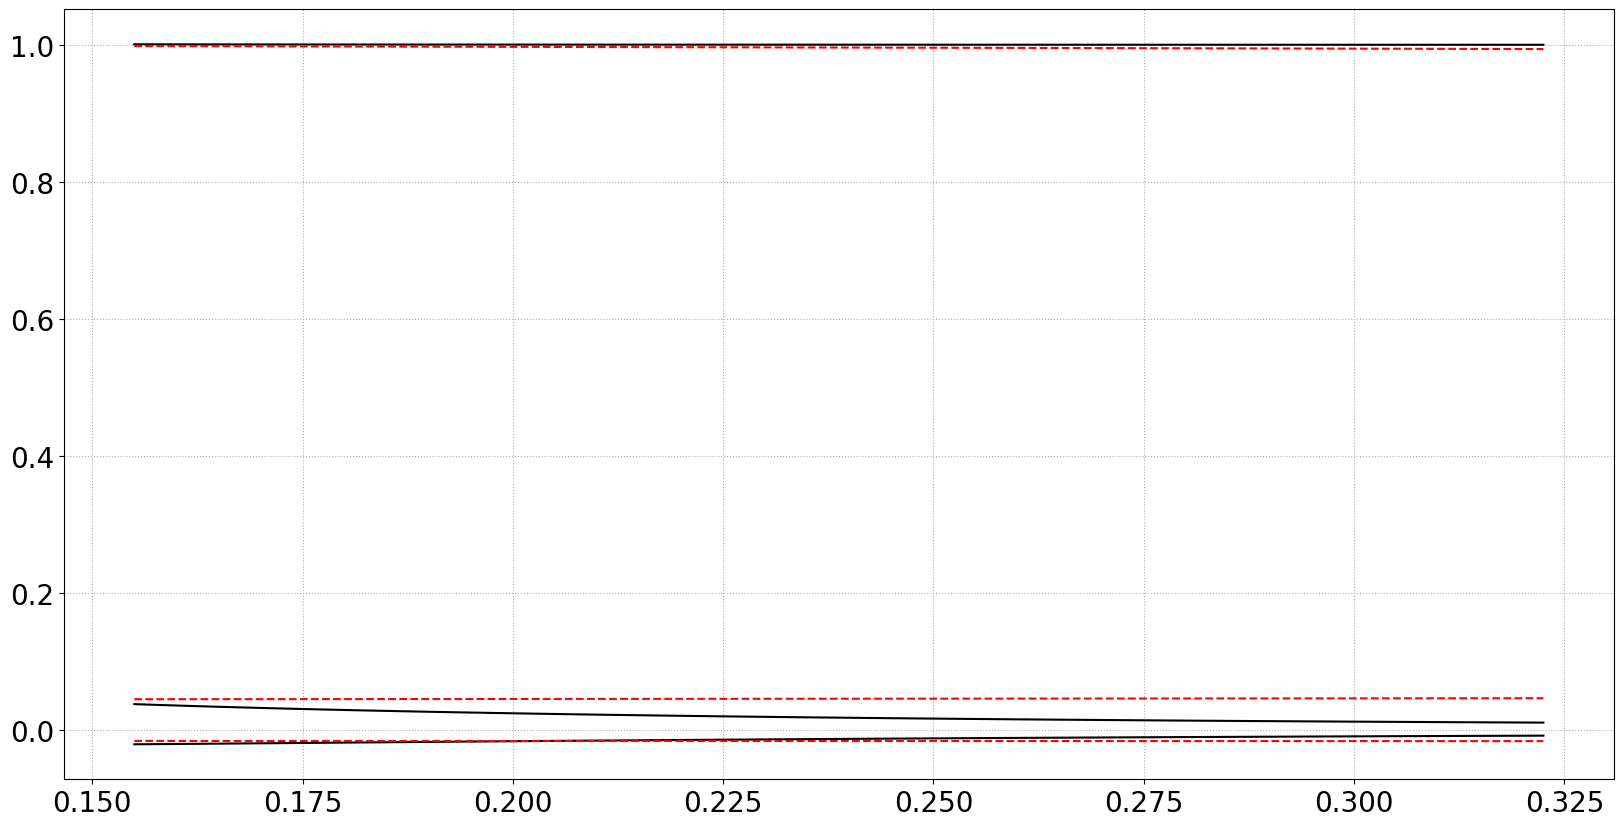

In [ ]:
PINN_model.test(N_val, UU_val)

In [ ]:
# def test(N_test, UU_test):
#         with torch.no_grad():
#             u_pred =  PINN_model.dnn(N_test)
#             error_vec = torch.linalg.norm((UU_test-u_pred[:,:3]),2)/torch.linalg.norm(UU_test,2)        # Relative L2 Norm of the error (Vector)
#             print('f_real = [0.01], f_PINN = [%.5f], Test Loss = [%.5f] ' %(torch.mean(u_pred[:,3]), error_vec))
#         return error_vec

# test(N_test, UU_test)

In [ ]:
#Training Loop 

# def train(PINN_model.Loss, train_loader, optimizer, criterion, epochs):
#     PINN_model.train()
#     losses = {}
#     ff = {}
#     for i in range(epochs):
#         running_loss = 0.0
#         for j, (X, Y, MF) in enumerate(train_loader):
#             optimizer.zero_grad()
#             loss = PINN_model.Loss(X, Y, MF)
#             loss.backward()
#             optimizer.step()
#             running_loss += loss.item() 
#         # Print the loss after every 10 batches
#         #if (i+1) % 10 == 0:
#          #   print(f" Epoch [{i+1}/{epochs}], Batch [{j+1}/{len(dataloader)}], Running Loss: {running_loss/10:.4f}, Loss: {loss.item():.4f}")
#           #  running_loss = 0.0


#         epoch_loss = running_loss/N 
#         losses[i] = epoch_loss
#         #writer.add_scalar("Loss/epoch", epoch_loss, i)
#         ff[i] = PINN_model.f.item()
#         #writer.add_scalar("Friction Factor/epoch", f.item(), i)

#         # Print the loss after each epoch
#         #print(f"Epoch [{i+1}/{epochs}], Loss: {loss.item():.4f}")

#         if i == epochs-1:
#             print(f"Epoch {i+1}/{epochs} - Loss: {epoch_loss:.6f}    f_Real: [0.01] - f_PINN:  {ff[i]:.6f}")
#         elif (i+1) % (epochs//5) == 0:
#             print(f"Epoch {i+1}/{epochs} - Loss: {epoch_loss:.6f}    f_Real: [0.01] - f_PINN:  {ff[i]:.6f}")

#     return losses, ff
    


In [ ]:
# Cross Validation

# def cross_validation(PINN_model, val_loader):
#     PINN_model.eval()
#     with torch.no_grad():
#         for X, Y, Z in val_loader:
#             pred = PINN_model.dnn(X)
#             error_vec = torch.linalg.norm((Y-pred),2)/torch.linalg.norm(Y,2)

#     return error_vec